In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import seaborn as sns
import netCDF4 as nc
import netCDF4, h5netcdf
from netCDF4 import Dataset
print("netCDF4:", netCDF4.__version__)
print("h5netcdf:", h5netcdf.__version__)
print("xarray:", xr.__version__)
import os
import glob
import matplotlib.pyplot as plt

netCDF4: 1.7.2
h5netcdf: 1.8.1
xarray: 2025.4.0


In [2]:
def process_data(path,var):
    datasets = []
    traj_counter=1
    for file in os.listdir(path):
        if file.endswith(".nc"):
            ds = xr.open_dataset(os.path.join(path, file))
    
            da = ds[var]  # (time, lat, lon)
        
            # cos(lat) weights for a regular lon grid
            w_lat = np.cos(np.deg2rad(ds["lat"]))
            # broadcast to lat,lon (xarray handles broadcasting):
            weights = w_lat
        
            # spatial mean for each time (area-weighted)
            fldmean = da.weighted(weights).mean(dim=("lat", "lon"))
            
            # time mean
            mean_weighted = fldmean.mean("time").item()
            #print("xarray area+time mean:", mean_weighted)
            
            # convert the spatial mean time series to DataFrame
            df_ts = fldmean.to_dataframe(name=var).reset_index()
            #print(df_ts.head())
            
            # DataFrame mean (should match rst_mean_weighted)
            #print("DataFrame mean:", df_ts[var].mean())
            df_ts["year"] = (df_ts["time"].astype(float) // 10000).astype(int)
            
            #print(df_ts[["time", "year"]].head())
            #print(df_ts['year'].unique())
            #make year counter variable
            # 11 copies of 1
            part1 = np.full(11, 1, dtype=int)
            
            # 12 copies of each integer from 2 to 144 (inclusive)
            part2 = np.repeat(np.arange(2, 145), 12)
            
            # one 145
            part3 = np.array([145], dtype=int)
            
            arr = np.concatenate([part1, part2, part3])
            #print(arr)
            #print("Length:", len(arr))
        
            s = pd.Series(arr, name="my_sequence")
            #print(s.head(20))
            
            df_ts['Years']=s
            df_ts['Trajectory']=traj_counter
            df_filtered=df_ts.loc[(df_ts['Years']<=140) & (df_ts['Years']>2)]
            
            datasets.append(df_filtered)
            traj_counter+=1
    
    
    
    
    # Ensure these datasets are compatible, then:
    ds_combined = pd.concat(datasets)
    return ds_combined

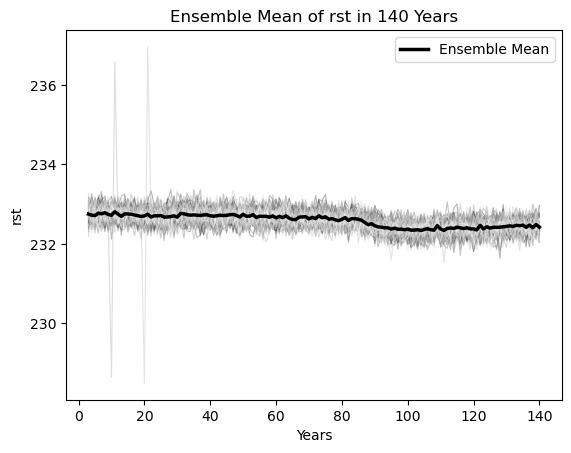

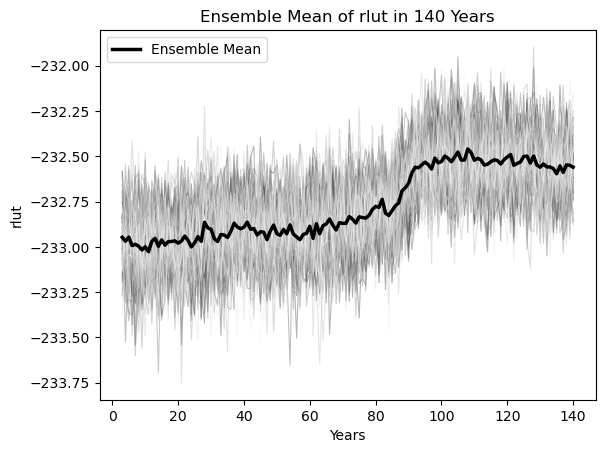

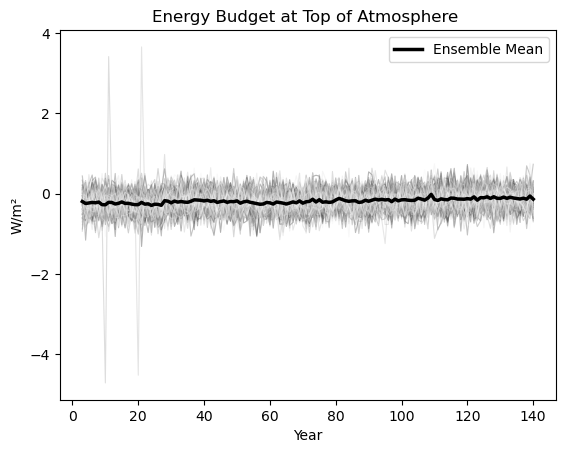

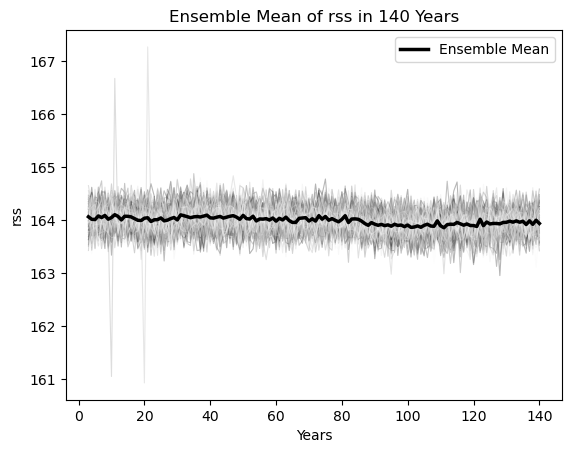

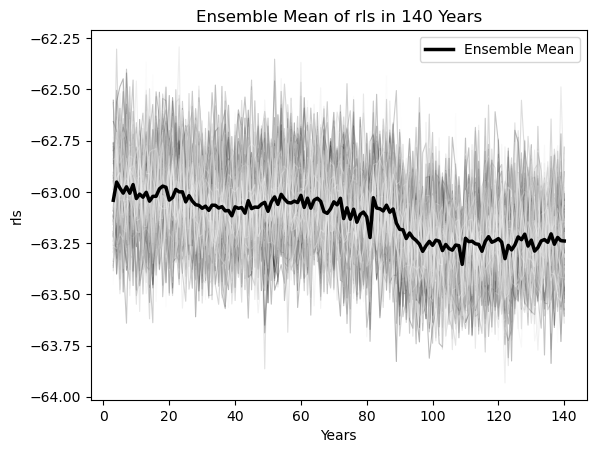

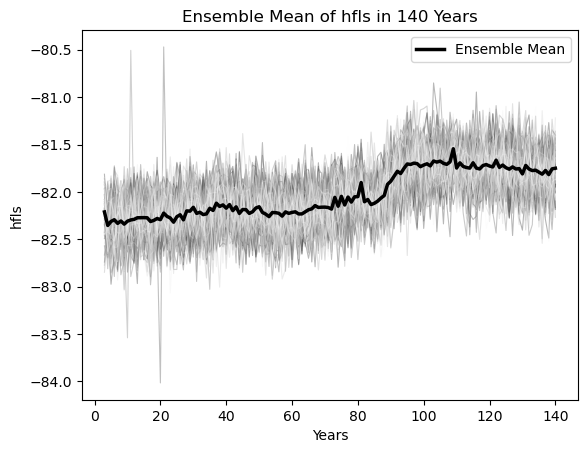

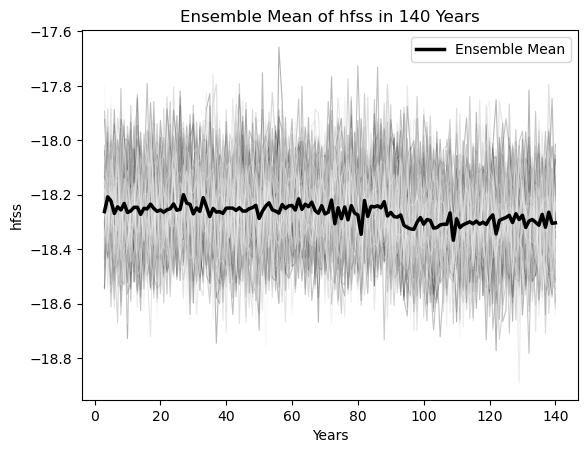

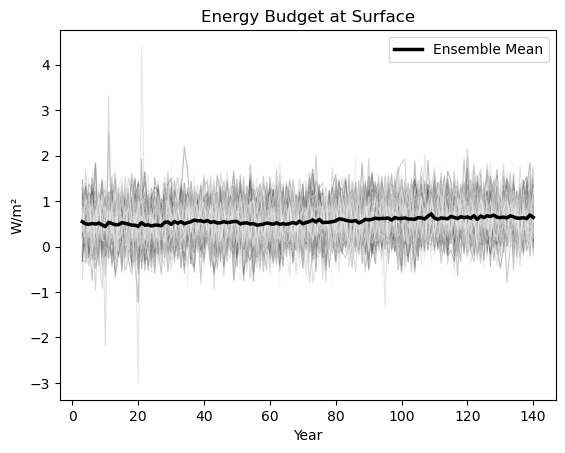

In [6]:
paths=['combined_rst/','combined_rlut','combined_rss','combined_rls','combined_hfls','combined_hfss']
varstrings=['rst','rlut','rss','rls','hfls','hfss']
#varnames=[rst,rlut,rss,rls,hfls,hfss]
#plotting
for path in range(len(paths)):
    #each variable
    vardf=f"{varstrings[path]}_df"
    vardf= process_data(paths[path],varstrings[path])
    df_yearly = vardf.groupby(["Years", "Trajectory"])[varstrings[path]].mean().reset_index()
    sns.lineplot(data=df_yearly,x="Years",y=varstrings[path],hue="Trajectory",palette="gray",         
    linewidth=0.8,
    alpha=0.3,
    legend=False)

    df_mean = df_yearly.groupby("Years")[varstrings[path]].mean().reset_index()
    
    sns.lineplot(
        data=df_mean,
        x="Years",
        y=varstrings[path],
        color="black",
        linewidth=2.5,
        label="Ensemble Mean"
    )
    plt.title(f"Ensemble Mean of {varstrings[path]} in 140 Years")
    plt.show()
    plt.close()

    #toa
    if (path==0):
        df_rst=df_yearly
    elif (path==1):
        df_rlut=df_yearly
        # Merge the two DataFrames on both "Years" and "Trajectory"
        df_combined = pd.merge(df_rst, df_rlut, on=["Years", "Trajectory"])
        
        # Create a new column which is the sum of rst and rss
        df_combined["total"] = df_combined["rst"] + df_combined["rlut"]
        
        # plot each trajectory timeseries
        sns.lineplot(data=df_combined, x="Years", y="total", hue="Trajectory",
                     palette="gray", linewidth=0.8, alpha=0.3, legend=False)
        
        # Compute the ensemble average (over trajectories) for each year
        df_mean = df_combined.groupby("Years")["total"].mean().reset_index()
        
        # Overlay the ensemble mean as a thick black line
        sns.lineplot(data=df_mean, x="Years", y="total", color="black", linewidth=2.5, label="Ensemble Mean")
        
        plt.title("Energy Budget at Top of Atmosphere ")
        plt.xlabel("Year")
        plt.ylabel("W/m²")
        plt.legend()
        plt.show()
        plt.close()

    #surface
    elif (path==2):
        df_rss=df_yearly
    elif (path==3):
        df_rls=df_yearly
    elif (path==4):
        df_hfls=df_yearly
    elif (path==5):
        df_hfss=df_yearly
        merged = pd.merge(df_rss, df_rls, on=["Years", "Trajectory"])
        merged = pd.merge(merged, df_hfls, on=["Years", "Trajectory"])
        merged = pd.merge(merged, df_hfss, on=["Years", "Trajectory"])
        merged['total'] = merged['rss'] + merged['rls'] + merged['hfls'] + merged['hfss']
        sns.lineplot(data=merged,x='Years',y='total',hue='Trajectory',palette='gray',linewidth=0.8, alpha=0.3,legend=False)
        surf_mean=merged.groupby("Years")["total"].mean().reset_index()
        sns.lineplot(data=surf_mean,x="Years",y="total",color="black",linewidth=2.5,label="Ensemble Mean")
        plt.title("Energy Budget at Surface")
        plt.xlabel("Year")
        plt.ylabel("W/m²")
        plt.show()
        plt.close()
        

In [9]:
def spatial_data(path,var,snapshot_year):
    datasets = []
    traj_counter = 1
    for file in os.listdir(path):
        if file.endswith(".nc"):
            ds = xr.open_dataset(os.path.join(path, file), engine="netcdf4")
            # Get the full data array (time, lat, lon)
            da = ds[var]
            #convert to df
            df_ts = da.to_dataframe(name=var).reset_index()
            df_ts["year"] = (df_ts["time"].astype(float) // 10000).astype(int)
            df_ts["Trajectory"] = traj_counter
            df_snapshot = df_ts.loc[df_ts["year"] == snapshot_year].copy()

            datasets.append(df_snapshot)
            traj_counter += 1
    return pd.concat(datasets, ignore_index=True)

path=1
for varname in range(len(varstrings)*2):
    if (varname<6):
        numberstring=f"{varstrings[varname]}_two"
        numberstring = spatial_data(paths[path],varstrings[path],2)
        path+=1
    elif (varname==6):
        path=1
    elif (varname>=6):
        numberstring=f"{varstrings[varname]}_hundred"
        numberstring = spatial_data(paths[path],varstrings[path],100)
        path+=1


IndexError: list index out of range